##Task 2: Empirical Diagnostic of Custom Weight Initializations and Gradient Vanishing
#Objective:
 Solve mathematical training instability in deep networks by analyzing activation
distributions and gradient magnitudes under varying initialization distributions.
#Required Tech Stack:
 PyTorch (with Autograd explicitly disabled via
requires_grad=False), NumPy, Matplotlib.
#Task Description:
Students will design custom Xavier (Glorot) and Kaiming (He) weight
initialization routines. They must write a tracking harness that hooks into an uninitialized
20-layer MLP to log and plot the mean and variance of intermediate activation vectors and
weight gradients across epochs, demonstrating gradient vanishing or explosion.

Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

Create Dataset

In [2]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_classes=3,
    n_informative=10,
    random_state=42
)

X = (X - X.mean(axis=0)) / X.std(axis=0)

num_classes = 3
Y = np.eye(num_classes)[y]

Network Configuration

In [3]:
layer_sizes = [20]

for i in range(20):
    layer_sizes.append(64)

layer_sizes.append(3)

print(layer_sizes)

[20, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 3]


Xavier Initialization

In [4]:
def xavier_init(layer_sizes):

    weights = []
    biases = []

    for i in range(len(layer_sizes)-1):

        fan_in = layer_sizes[i]
        fan_out = layer_sizes[i+1]

        limit = np.sqrt(6/(fan_in+fan_out))

        W = np.random.uniform(
            -limit,
            limit,
            (fan_in,fan_out)
        )

        b = np.zeros((1,fan_out))

        weights.append(W)
        biases.append(b)

    return weights,biases

He Initialization

In [5]:
def he_init(layer_sizes):

    weights=[]
    biases=[]

    for i in range(len(layer_sizes)-1):

        fan_in=layer_sizes[i]

        W=np.random.randn(
            fan_in,
            layer_sizes[i+1]
        )*np.sqrt(2/fan_in)

        b=np.zeros((1,layer_sizes[i+1]))

        weights.append(W)
        biases.append(b)

    return weights,biases

ReLU

In [6]:
def relu(x):
    return np.maximum(0,x)

def relu_derivative(x):
    return (x>0).astype(float)

Softmax

In [7]:
def softmax(x):

    exp=np.exp(x-np.max(x,axis=1,keepdims=True))

    return exp/np.sum(exp,axis=1,keepdims=True)

Forward Propagation

In [8]:
def forward(X,weights,biases):

    activations=[X]
    zs=[]

    A=X

    for i in range(len(weights)-1):

        Z=np.dot(A,weights[i])+biases[i]

        A=relu(Z)

        zs.append(Z)
        activations.append(A)

    Z=np.dot(A,weights[-1])+biases[-1]

    A=softmax(Z)

    zs.append(Z)
    activations.append(A)

    return activations,zs

Cross Entropy

In [9]:
def cross_entropy(pred,Y):

    pred=np.clip(pred,1e-12,1)

    return -np.mean(np.sum(Y*np.log(pred),axis=1))

Backpropagation

In [10]:
def backward(activations,zs,Y,weights):

    grads=[]

    m=Y.shape[0]

    dZ=(activations[-1]-Y)/m

    for i in reversed(range(len(weights))):

        dW=np.dot(
            activations[i].T,
            dZ
        )

        db=np.sum(
            dZ,
            axis=0,
            keepdims=True
        )

        grads.insert(0,(dW,db))

        if i>0:

            dA=np.dot(
                dZ,
                weights[i].T
            )

            dZ=dA*relu_derivative(zs[i-1])

    return grads

Update

In [11]:
def update(weights,biases,grads,lr):

    for i in range(len(weights)):

        weights[i]-=lr*grads[i][0]

        biases[i]-=lr*grads[i][1]

Training Function

In [12]:
def train(weights,biases,name):

    losses=[]

    activation_mean=[]
    activation_var=[]

    gradient_mean=[]
    gradient_var=[]

    for epoch in range(100):

        activations,zs=forward(X,weights,biases)

        loss=cross_entropy(
            activations[-1],
            Y
        )

        grads=backward(
            activations,
            zs,
            Y,
            weights
        )

        update(
            weights,
            biases,
            grads,
            0.01
        )

        losses.append(loss)

        activation_mean.append(
            np.mean(activations[10])
        )

        activation_var.append(
            np.var(activations[10])
        )

        gradient_mean.append(
            np.mean(grads[10][0])
        )

        gradient_var.append(
            np.var(grads[10][0])
        )

    return (
        losses,
        activation_mean,
        activation_var,
        gradient_mean,
        gradient_var
    )

Train Xavier

In [13]:
weights,biases=xavier_init(layer_sizes)

x_loss,x_mean,x_var,x_gmean,x_gvar=train(
    weights,
    biases,
    "Xavier"
)

Train He

In [14]:
weights,biases=he_init(layer_sizes)

h_loss,h_mean,h_var,h_gmean,h_gvar=train(
    weights,
    biases,
    "He"
)

Plot Loss

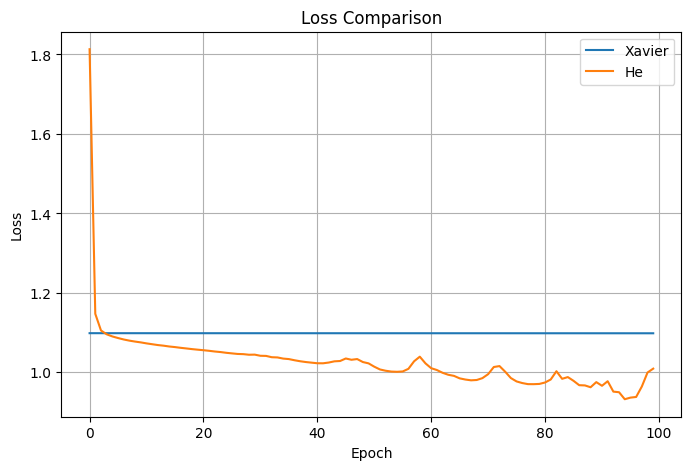

In [15]:
plt.figure(figsize=(8,5))
plt.plot(x_loss,label="Xavier")
plt.plot(h_loss,label="He")
plt.title("Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

Activation Statistics

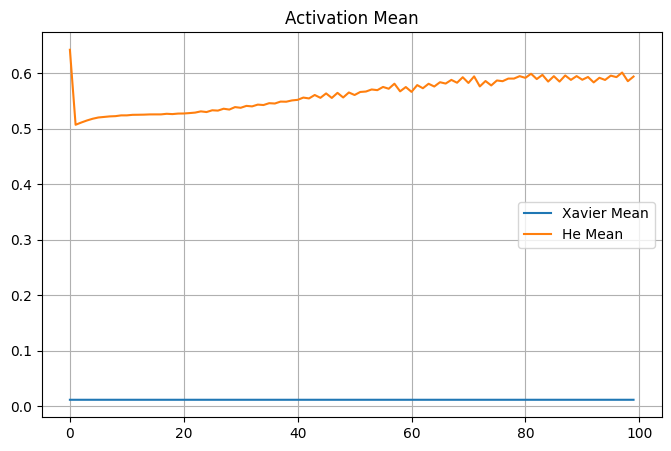

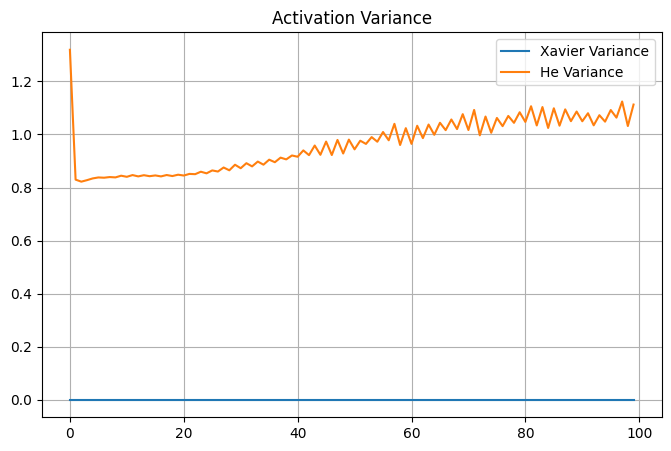

In [16]:
plt.figure(figsize=(8,5))
plt.plot(x_mean,label="Xavier Mean")
plt.plot(h_mean,label="He Mean")
plt.title("Activation Mean")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(x_var,label="Xavier Variance")
plt.plot(h_var,label="He Variance")
plt.title("Activation Variance")
plt.legend()
plt.grid()
plt.show()

Gradient Statistics

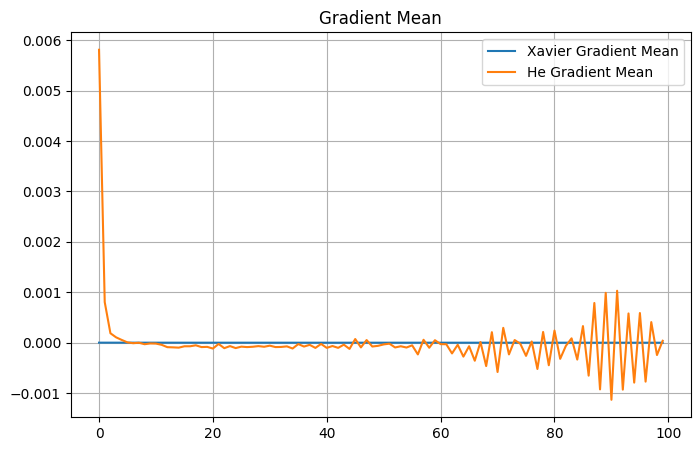

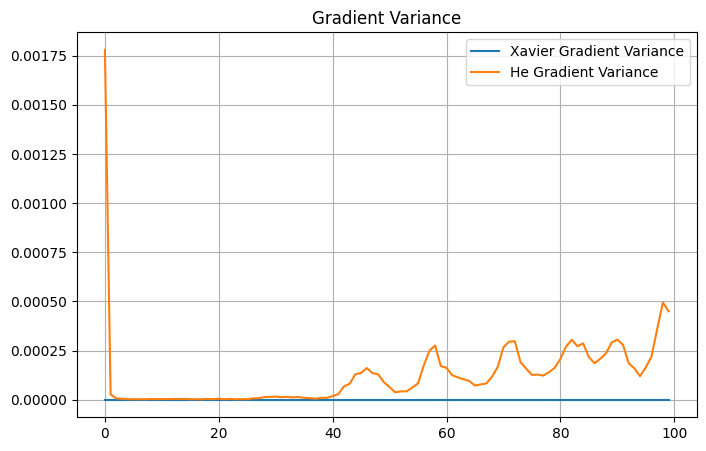

In [17]:
plt.figure(figsize=(8,5))
plt.plot(x_gmean,label="Xavier Gradient Mean")
plt.plot(h_gmean,label="He Gradient Mean")
plt.title("Gradient Mean")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(x_gvar,label="Xavier Gradient Variance")
plt.plot(h_gvar,label="He Gradient Variance")
plt.title("Gradient Variance")
plt.legend()
plt.grid()
plt.show()